In [19]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.text import Tokenizer
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt




In [20]:


# Load dataset from CSV, skipping problematic lines
data = pd.read_csv("/content/imdb.csv", on_bad_lines='skip') # change name if needed
data

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [21]:
# Columns: review, sentiment
X = data['review']
y = data['sentiment'].map({'positive': 1, 'negative': 0})

In [22]:
# Train-test split
X_train_text, X_test_text, y_train, y_test = train_test_split(X, y, test_size=0.2)


In [23]:
# Convert text → sequences
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(X_train_text)

X_train = tokenizer.texts_to_sequences(X_train_text)
X_test = tokenizer.texts_to_sequences(X_test_text)

# Pad sequences (same as your code)
X_train = keras.preprocessing.sequence.pad_sequences(X_train, maxlen=200)
X_test = keras.preprocessing.sequence.pad_sequences(X_test, maxlen=200)

In [24]:
# Model (same)
model = keras.Sequential([
    layers.Embedding(10000, 128),
    layers.Flatten(),
    layers.Dense(1, activation='sigmoid')
])

In [25]:
# Compile (same)
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])


In [14]:
history = model.fit(X_train, y_train, epochs=3, validation_split=0.2)

Epoch 1/3
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.8181 - loss: 0.3860 - val_accuracy: 0.8746 - val_loss: 0.2935
Epoch 2/3
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.9524 - loss: 0.1395 - val_accuracy: 0.8831 - val_loss: 0.2877
Epoch 3/3
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 0.9950 - loss: 0.0307 - val_accuracy: 0.8840 - val_loss: 0.3231


In [26]:
loss, acc = model.evaluate(X_test, y_test)
print("Accuracy:", acc)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5068 - loss: 0.6931
Accuracy: 0.5067999958992004


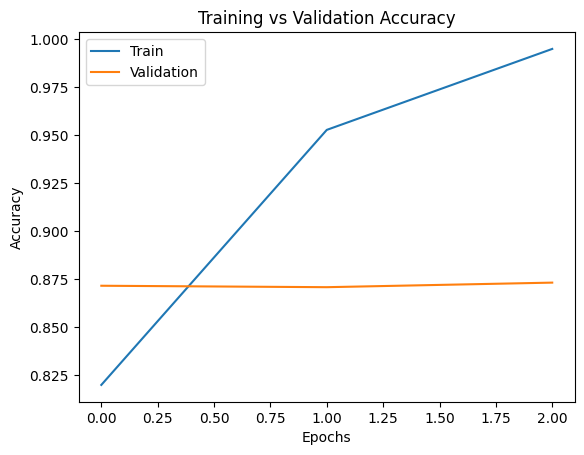

In [27]:
# Plot Accuracy (same)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.show()